# Day 5 — Hourly Demand Forecasting

## Objective

Forecast future hourly order demand using time-series models
(ARIMA and Prophet), based on historical order timestamps.

## Part 1 — Prepare Time Series

The raw data has one row per order, with a timestamp for when the
order was placed. To forecast demand, we first need to convert this
into a time series: the number of orders placed in each hour.

In [2]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the orders dataset

orders1 = pd.read_csv('../data/processed/orders_clean.csv')
orders = orders1.copy()

# Convert order timestamp to datetime

orders['order_timestamp'] = pd.to_datetime(
    orders['order_timestamp']
)

# Display the date range covered by the data

print('Earliest order:', orders['order_timestamp'].min())
print('Latest order:', orders['order_timestamp'].max())
print('Total orders:', len(orders))

Earliest order: 2025-01-01 06:23:45
Latest order: 2025-06-30 23:55:18
Total orders: 10000


### Aggregating to Hourly Order Volume

Each order is grouped by the hour it was placed in, and the number of
orders in each hour is counted. Hours with no orders are filled in
with a count of 0, so that the resulting time series has one
continuous row per hour with no missing timestamps.

In [3]:
# Round each order timestamp down to the hour

orders['order_hour_ts'] = orders['order_timestamp'].dt.floor('h')

# Count the number of orders in each hour

hourly_demand = (
    orders
    .groupby('order_hour_ts')
    .size()
    .rename('order_count')
)

# Create a complete range of hours covering the full data period,
# so that hours with zero orders are included

full_hour_range = pd.date_range(
    start=orders['order_hour_ts'].min(),
    end=orders['order_hour_ts'].max(),
    freq='h'
)

hourly_demand = hourly_demand.reindex(
    full_hour_range,
    fill_value=0
)

hourly_demand.index.name = 'order_hour_ts'

# Display the shape and first few rows

print('Shape:', hourly_demand.shape)
hourly_demand.head(10)

Shape: (4338,)


order_hour_ts
2025-01-01 06:00:00    1
2025-01-01 07:00:00    0
2025-01-01 08:00:00    1
2025-01-01 09:00:00    1
2025-01-01 10:00:00    3
2025-01-01 11:00:00    3
2025-01-01 12:00:00    2
2025-01-01 13:00:00    1
2025-01-01 14:00:00    1
2025-01-01 15:00:00    2
Freq: h, Name: order_count, dtype: int64

## Part 2 — Exploratory Analysis

Before modeling, we look at the hourly order volume visually to
identify trends, repeating patterns, and peak periods.

### Weekend vs Weekday Pattern

In addition to individual day-of-week averages, we specifically
compare weekday demand against weekend demand to check whether
weekends show meaningfully different ordering behavior.

Weekday    2.306796
Weekend    2.301282
Name: order_count, dtype: float64


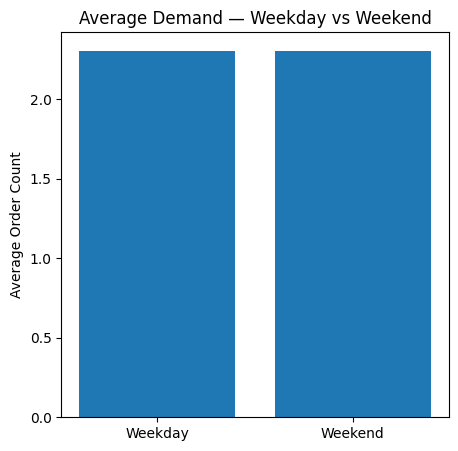

In [13]:
# Flag whether each hour falls on a weekend

hourly_df['is_weekend'] = hourly_df['order_hour_ts'].dt.dayofweek >= 5

# Average order count: weekday vs weekend

avg_by_weekend = hourly_df.groupby('is_weekend')['order_count'].mean()
avg_by_weekend.index = ['Weekday', 'Weekend']

# Display and plot

print(avg_by_weekend)

plt.figure(figsize=(5, 5))
plt.bar(avg_by_weekend.index, avg_by_weekend.values)
plt.ylabel('Average Order Count')
plt.title('Average Demand — Weekday vs Weekend')
plt.show()

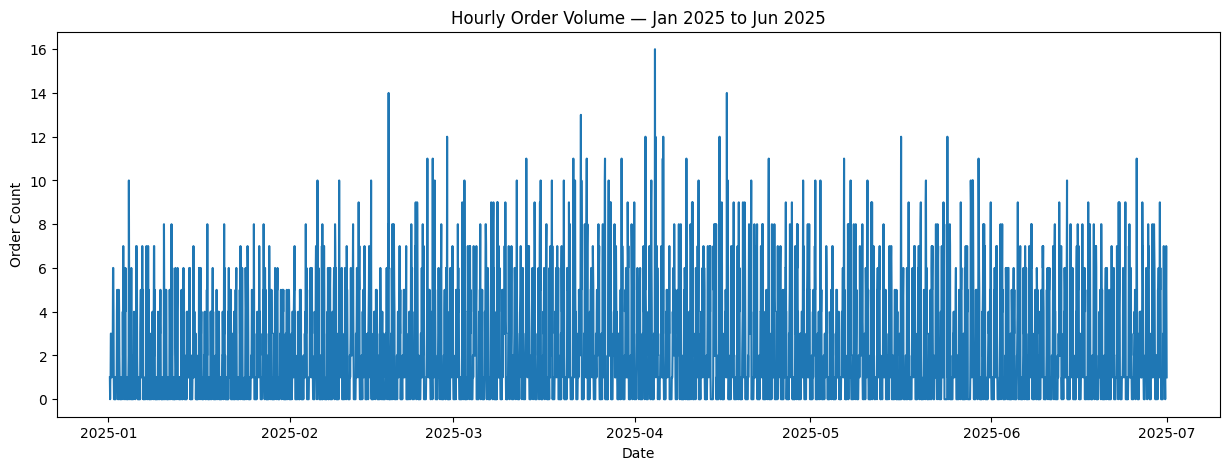

In [4]:
# Plot the full hourly order volume time series

plt.figure(figsize=(15, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values
)

plt.xlabel('Date')
plt.ylabel('Order Count')
plt.title('Hourly Order Volume — Jan 2025 to Jun 2025')

plt.show()

### Average Demand by Hour of Day and Day of Week

To identify repeating patterns, we look at average order volume by
hour of day (0–23) and by day of week, separately from the raw
hour-by-hour series above.

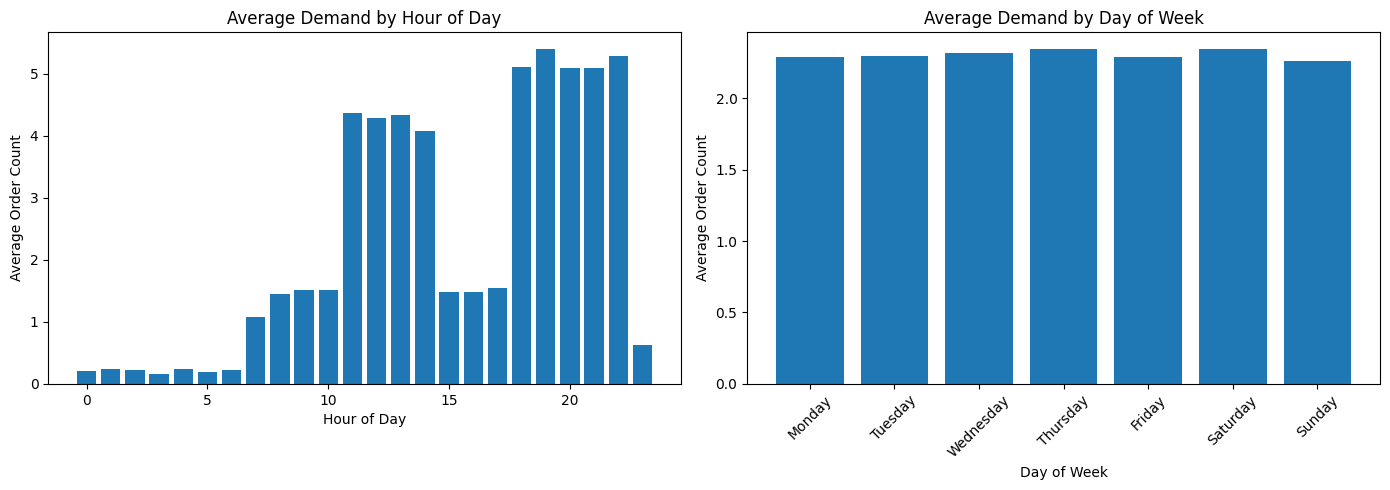

In [6]:
# Create a working copy with hour and day-of-week extracted

hourly_df = hourly_demand.reset_index()
hourly_df.columns = ['order_hour_ts', 'order_count']

hourly_df['hour_of_day'] = hourly_df['order_hour_ts'].dt.hour
hourly_df['day_of_week'] = hourly_df['order_hour_ts'].dt.day_name()

# Average order count by hour of day

avg_by_hour = hourly_df.groupby('hour_of_day')['order_count'].mean()

# Average order count by day of week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_day = hourly_df.groupby('day_of_week')['order_count'].mean().reindex(day_order)

# Plot both

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(avg_by_hour.index, avg_by_hour.values)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Order Count')
axes[0].set_title('Average Demand by Hour of Day')

axes[1].bar(avg_by_day.index, avg_by_day.values)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Order Count')
axes[1].set_title('Average Demand by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Part 3 — Time-Series Decomposition

Decomposition splits a time series into three components:

- Trend: the long-term direction of the series (increasing,
  decreasing, or flat).
- Seasonality: a repeating pattern at a fixed interval (in our case,
  the 24-hour daily cycle observed above).
- Residual: whatever remains after removing trend and seasonality,
  representing noise or irregular variation.

We use an additive model, since the daily pattern appears to have a
roughly constant size across the whole period rather than growing
with the level of demand.

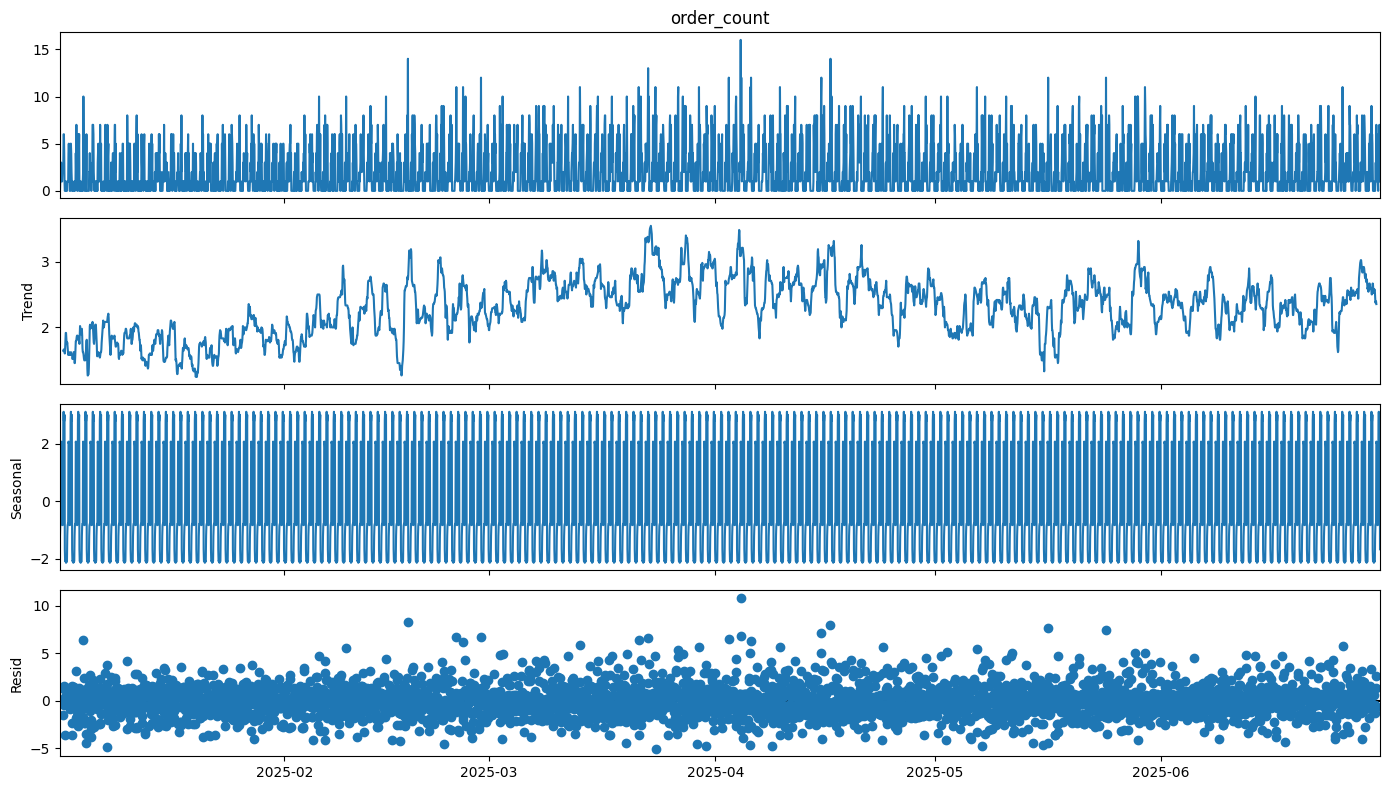

In [7]:
# Import decomposition tool

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the hourly series using a 24-hour period (daily seasonality)

decomposition = seasonal_decompose(
    hourly_demand,
    model='additive',
    period=24
)

# Plot the decomposition

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

## Part 4 — Stationarity

ARIMA models require the time series to be stationary, meaning its
statistical properties (mean, variance) do not change over time. The
Augmented Dickey-Fuller (ADF) test is a statistical test used to
check this.

The null hypothesis of the ADF test is that the series is
non-stationary. If the p-value is below 0.05, we reject the null
hypothesis and conclude the series is stationary.

### Why Stationarity Matters for ARIMA

ARIMA assumes the statistical properties of the series (mean,
variance) stay constant over time. If a series has a strong trend or
changing variance, ARIMA's autoregressive and moving-average terms
cannot reliably model it, since the relationship between past and
future values would itself be changing. This is why the ADF test is
run before fitting ARIMA, and why differencing (the "I" in ARIMA) is
applied when needed to remove trend and stabilize the series before
modeling.

In [9]:
# Import the ADF test

from statsmodels.tsa.stattools import adfuller

# Run the ADF test on the hourly order volume series

adf_result = adfuller(hourly_demand)

# Display the results

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -6.727151051789074
p-value: 3.3670783289567695e-09
Critical Values:
   1%: -3.4318692016852586
   5%: -2.862211299096659
   10%: -2.5671273374028565


### ADF Test Result

The p-value is well below 0.05, so the null hypothesis of
non-stationarity is rejected. The hourly order volume series is
stationary, and no differencing is required before fitting ARIMA.

## Chronological Train/Test Split

Since this is time-series data, we cannot randomly shuffle rows into
train and test sets, as that would let the model "see" future values
while training. Instead, the data is split by date: earlier
observations are used for training, and the most recent period is
held out for testing.

The last 2 weeks of the data (roughly 336 hours) are used as the test
set, and everything before that is used for training.

In [10]:
# Define the split point: last 2 weeks held out for testing

split_date = hourly_demand.index.max() - pd.Timedelta(days=14)

train = hourly_demand[hourly_demand.index <= split_date]
test = hourly_demand[hourly_demand.index > split_date]

# Display the resulting sizes and date ranges

print('Training set:', train.shape, '|', train.index.min(), 'to', train.index.max())
print('Test set:', test.shape, '|', test.index.min(), 'to', test.index.max())

Training set: (4002,) | 2025-01-01 06:00:00 to 2025-06-16 23:00:00
Test set: (336,) | 2025-06-17 00:00:00 to 2025-06-30 23:00:00


## Part 5 — ARIMA

ARIMA (AutoRegressive Integrated Moving Average) forecasts a value
based on its own past values (AR), the degree of differencing needed
for stationarity (I), and past forecast errors (MA). It is specified
with three parameters (p, d, q).

Since the ADF test already showed the series is stationary, d is set
to 0 (no differencing needed). We start with a simple order and can
adjust based on results.

In [11]:
# Import ARIMA

from statsmodels.tsa.arima.model import ARIMA

# Fit an ARIMA model on the training data
# order=(p, d, q): p=2 past values, d=0 no differencing, q=2 past errors

arima_model = ARIMA(
    train,
    order=(2, 0, 2)
)

arima_fit = arima_model.fit()

# Display model summary

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            order_count   No. Observations:                 4002
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -8792.559
Date:                Wed, 19 Aug 2026   AIC                          17597.117
Time:                        11:54:30   BIC                          17634.884
Sample:                    01-01-2025   HQIC                         17610.504
                         - 06-16-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3005      0.048     48.230      0.000       2.207       2.394
ar.L1          1.6481      0.026     63.001      0.000       1.597       1.699
ar.L2         -0.7339      0.024    -30.119      0.0

### ARIMA Forecast

The fitted model is used to forecast order volume for the same period
covered by the test set, so predictions can be compared against
actual values.

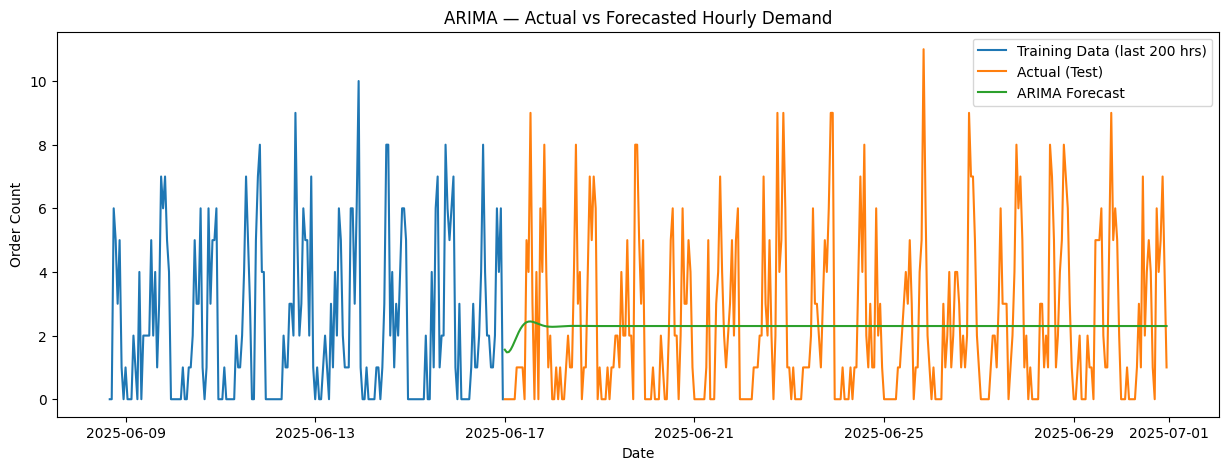

In [12]:
# Generate forecasts for the length of the test set

arima_forecast = arima_fit.forecast(steps=len(test))

# Plot actual vs forecasted values

plt.figure(figsize=(15, 5))

plt.plot(train.index[-200:], train.values[-200:], label='Training Data (last 200 hrs)')
plt.plot(test.index, test.values, label='Actual (Test)')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')

plt.xlabel('Date')
plt.ylabel('Order Count')
plt.title('ARIMA — Actual vs Forecasted Hourly Demand')
plt.legend()

plt.show()

### ARIMA Forecast — Conclusion

The ARIMA(2,0,2) forecast converges quickly to a near-constant value
of approximately 2.3 orders per hour, which matches the overall mean
of the series. It does not reproduce the repeating daily peaks and
troughs seen in the actual test data (near 0 overnight, up to 9-11
during peak hours).

This happens because the chosen ARIMA order does not include a
seasonal component, so the model has no way to represent the 24-hour
cycle identified during decomposition. As a result, this model is
not well suited for hourly demand forecasting in its current form,
and its forecast accuracy will be evaluated numerically in the
model comparison step alongside Prophet.

## Part 6 — Prophet

Prophet is a forecasting model designed to handle time series with
strong seasonal patterns, and it can incorporate daily, weekly, and
yearly seasonality directly, along with holiday effects. This makes
it well suited to the daily ordering pattern identified earlier in
this analysis.

Prophet expects the input data in a specific format: a column named
'ds' for the timestamp and a column named 'y' for the value being
forecast.

In [15]:
# Import Prophet

from prophet import Prophet

# Prepare the training data in Prophet's required format

prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

# Prepare the test data the same way, for later comparison

prophet_test = test.reset_index()
prophet_test.columns = ['ds', 'y']

# Display the first few rows

prophet_train.head()

/home/nineleaps/Documents/da_python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,ds,y
0,2025-01-01 06:00:00,1
1,2025-01-01 07:00:00,0
2,2025-01-01 08:00:00,1
3,2025-01-01 09:00:00,1
4,2025-01-01 10:00:00,3


### Fitting the Prophet Model

Prophet is fit on the training data, with daily seasonality enabled
since that is the main repeating pattern identified earlier. Weekly
seasonality is left on by default, though the earlier day-of-week
analysis showed it is likely weak.

In [16]:
# Create and fit the Prophet model

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_train)

12:13:23 - cmdstanpy - INFO - Chain [1] start processing
12:13:23 - cmdstanpy - INFO - Chain [1] done processing


### Generating Forecasts

Prophet forecasts are generated for the same period covered by the
test set, so predictions can be compared against actual values.

In [17]:
# Create a dataframe of future timestamps matching the test period

future = prophet_test[['ds']]

# Generate forecasts

prophet_forecast = prophet_model.predict(future)

# Display the key forecast columns

prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2025-06-17 00:00:00,0.547290,-1.573064,2.577295
1,2025-06-17 01:00:00,0.111210,-2.070035,2.263427
2,2025-06-17 02:00:00,0.058402,-2.066415,2.175607
3,2025-06-17 03:00:00,0.102205,-2.003502,2.268674
4,2025-06-17 04:00:00,0.183067,-2.103519,2.381173


### Prophet Forecast — Actual vs Predicted

The Prophet forecast is plotted against actual test-set values to
visually assess how well it captures the daily demand pattern.

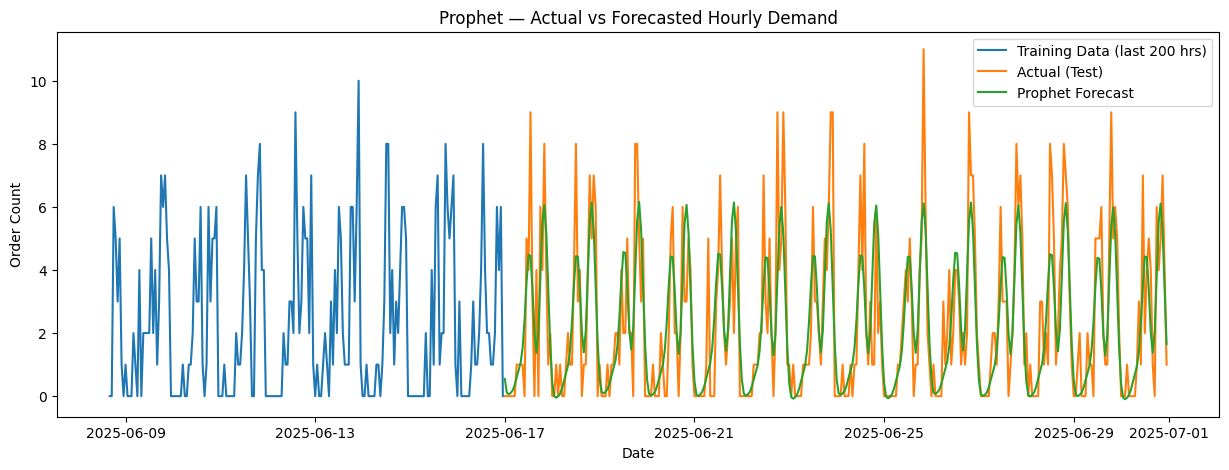

In [18]:
# Plot actual vs forecasted values

plt.figure(figsize=(15, 5))

plt.plot(train.index[-200:], train.values[-200:], label='Training Data (last 200 hrs)')
plt.plot(prophet_test['ds'], prophet_test['y'], label='Actual (Test)')
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast')

plt.xlabel('Date')
plt.ylabel('Order Count')
plt.title('Prophet — Actual vs Forecasted Hourly Demand')
plt.legend()

plt.show()

### Prophet Forecast — Conclusion

Unlike ARIMA, the Prophet forecast follows the daily seasonal pattern
in the test data, rising and falling in line with actual peak and
off-peak hours. It does not match every individual spike, but it
captures the underlying repeating structure identified during
decomposition. This will be confirmed numerically in the next step,
where ARIMA and Prophet are compared using MAE, RMSE, and MAPE.

## Part 8 — Model Comparison

ARIMA and Prophet forecasts are compared on the same test set using
three metrics: MAE, RMSE, and MAPE (Mean Absolute Percentage Error).
MAPE expresses error as a percentage, which is easier to interpret,
though it can be unstable when actual values are close to zero — a
relevant consideration here, since many hours have 0 or 1 orders.

In [20]:
# Import evaluation metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate MAE and RMSE for ARIMA

arima_mae = mean_absolute_error(test.values, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test.values, arima_forecast))

# Calculate MAE and RMSE for Prophet

prophet_mae = mean_absolute_error(prophet_test['y'], prophet_forecast['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_forecast['yhat']))

# Display results

print('ARIMA   - MAE:', round(arima_mae, 2), '| RMSE:', round(arima_rmse, 2))
print('Prophet - MAE:', round(prophet_mae, 2), '| RMSE:', round(prophet_rmse, 2))

ARIMA   - MAE: 2.02 | RMSE: 2.47
Prophet - MAE: 1.04 | RMSE: 1.48


### Model Comparison — Conclusion

Prophet outperformed ARIMA on both metrics, with roughly half the
error: MAE of 1.04 vs 2.02, and RMSE of 1.48 vs 2.47. This is
consistent with the forecast plots, where Prophet tracked the daily
peak/off-peak pattern in demand while ARIMA converged to a flat
average. For this dataset, Prophet is the better-suited model,
primarily because it explicitly models the daily seasonality that
ARIMA(2,0,2) did not account for.

## Final Demand Forecast

Using Prophet, the better-performing model, we generate a forecast
for the week immediately following the end of the available data,
to illustrate what a forward-looking demand forecast looks like in
practice.

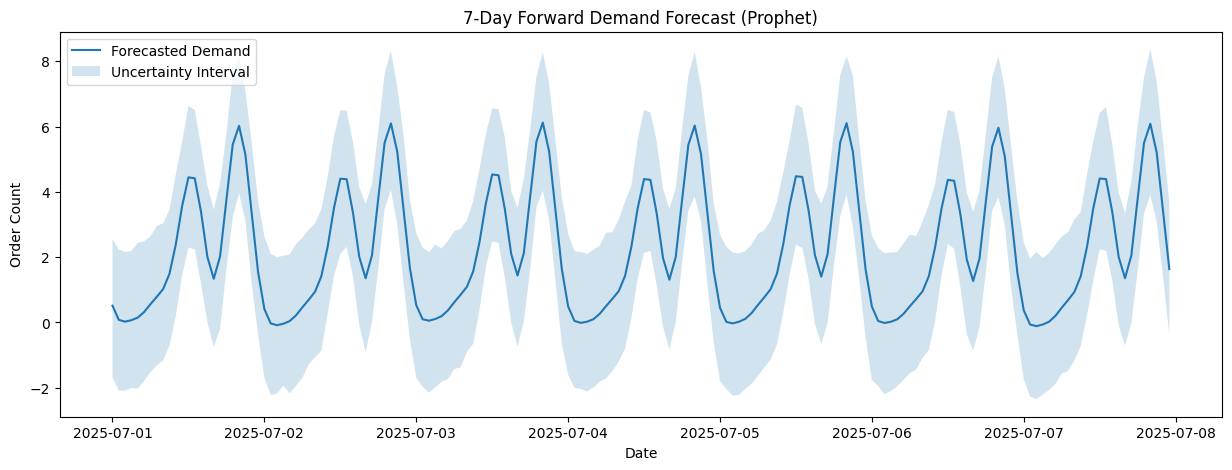

In [21]:
# Create future timestamps for the 7 days after the last known date

future_dates = pd.date_range(
    start=hourly_demand.index.max() + pd.Timedelta(hours=1),
    periods=24 * 7,
    freq='h'
)

future_df = pd.DataFrame({'ds': future_dates})

# Generate the forecast

final_forecast = prophet_model.predict(future_df)

# Plot the forecast

plt.figure(figsize=(15, 5))

plt.plot(final_forecast['ds'], final_forecast['yhat'], label='Forecasted Demand')
plt.fill_between(
    final_forecast['ds'],
    final_forecast['yhat_lower'],
    final_forecast['yhat_upper'],
    alpha=0.2,
    label='Uncertainty Interval'
)

plt.xlabel('Date')
plt.ylabel('Order Count')
plt.title('7-Day Forward Demand Forecast (Prophet)')
plt.legend()

plt.show()

### Final Forecast — Conclusion

The 7-day forward forecast reproduces the same repeating daily
pattern identified throughout this analysis, with two demand peaks
(midday and evening) and a trough overnight, consistent across all 7
forecasted days. This confirms that Prophet has learned the daily
seasonal structure rather than just fitting noise.

The uncertainty interval is fairly wide relative to the forecast
values, and briefly dips below 0 during the lowest-demand hours. This
is a known limitation of Prophet's default uncertainty modeling for
sparse, low-count data, and should be kept in mind when using the
interval bounds directly, since order counts cannot be negative.

### Business Interpretation

Order demand follows a highly consistent daily cycle, with two peak
periods (midday and evening) and very low demand overnight. Day-of-
week and weekday/weekend differences are minimal, meaning demand
planning can be based primarily on time of day rather than which day
it is.

Prophet's ability to capture this daily cycle, compared to ARIMA's
flat forecast, makes it the more suitable model for operational use
here — for example, forecasting driver staffing needs by hour, or
anticipating kitchen preparation load during peak windows.

Since forecast uncertainty is wider during low-demand overnight hours
and narrower during peak hours, forecasts are most reliable for
planning around the two daily peaks, which is also when accurate
staffing matters most.